# Assignment 9: Using a Variational Autoencoder for Compression and Denoising

**Name:** Varshith Kumar R


**Class:** BCA


**Objective:** explore two practical applications of a VAE on MNIST: (1) data compression and (2) image denoising.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [2]:
# Load MNIST (pixel values scaled to [0, 1])
tfm = transforms.ToTensor()
train_ds = datasets.MNIST('./data', train=True, download=True, transform=tfm)
test_ds = datasets.MNIST('./data', train=False, download=True, transform=tfm)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1000, shuffle=False)
print(len(train_ds), 'training images,', len(test_ds), 'test images')

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.1MB/s]

60000 training images, 10000 test images


## 1. VAE model (from Assignment 8) and training

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        # Encoder
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
        # Decoder
        self.fc3 = nn.Linear(latent_dim, 256)
        self.fc4 = nn.Linear(256, 512)
        self.fc5 = nn.Linear(512, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x.view(-1, 784)))
        h = F.relu(self.fc2(h))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))
        return torch.sigmoid(self.fc5(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon, x, mu, logvar):
    bce = F.binary_cross_entropy(recon, x.view(-1, 784), reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (bce + kld) / x.size(0)


def train_vae(latent_dim, epochs=20, lr=1e-3):
    model = VAE(latent_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            opt.zero_grad()
            recon, mu, logvar = model(x)
            loss = vae_loss(recon, x, mu, logvar)
            loss.backward()
            opt.step()
            total += loss.item() * x.size(0)
        if epoch == 1 or epoch % 5 == 0:
            print(f'[latent={latent_dim}] epoch {epoch:2d}/{epochs}  loss/sample = {total / len(train_ds):.2f}')
    return model.eval()

In [4]:
# Train one VAE per latent size (2 = Assignment 8, 16 and 32 = Part D)
latent_dims = [2, 16, 32]
models = {d: train_vae(d, epochs=20) for d in latent_dims}

[latent=2] epoch  1/20  loss/sample = 182.23
[latent=2] epoch  5/20  loss/sample = 148.78
[latent=2] epoch 10/20  loss/sample = 143.23
[latent=2] epoch 15/20  loss/sample = 140.58
[latent=2] epoch 20/20  loss/sample = 139.02
[latent=16] epoch  1/20  loss/sample = 175.50
[latent=16] epoch  5/20  loss/sample = 110.01
[latent=16] epoch 10/20  loss/sample = 103.75
[latent=16] epoch 15/20  loss/sample = 101.31
[latent=16] epoch 20/20  loss/sample = 99.89
[latent=32] epoch  1/20  loss/sample = 179.04
[latent=32] epoch  5/20  loss/sample = 110.21
[latent=32] epoch 10/20  loss/sample = 103.47
[latent=32] epoch 15/20  loss/sample = 101.12
[latent=32] epoch 20/20  loss/sample = 99.77


## Helper functions

In [5]:
@torch.no_grad()
def reconstruct(model, x):
    """Encode -> decode. Uses the mean mu as the latent code (deterministic, no sampling noise)."""
    mu, _ = model.encode(x.to(device))
    return model.decode(mu).cpu().view(-1, 1, 28, 28)


def per_image_mse(a, b):
    return ((a - b) ** 2).view(a.size(0), -1).mean(dim=1)


def show_rows(rows, row_names, col_titles=None, title=None):
    n_rows, n_cols = len(rows), rows[0].size(0)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.4 * n_cols, 1.6 * n_rows))
    for r in range(n_rows):
        for c in range(n_cols):
            ax = axes[r, c]
            ax.imshow(rows[r][c].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if c == 0:
                ax.set_ylabel(row_names[r], rotation=0, ha='right', va='center', fontsize=9)
            if r == 0 and col_titles is not None:
                ax.set_title(col_titles[c], fontsize=8)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


# The same 10 test images are used in Parts B, C and D
x10 = torch.stack([test_ds[i][0] for i in range(10)])
y10 = [test_ds[i][1] for i in range(10)]
digit_titles = [f'digit {y}' for y in y10]

## Part A: Compression

- Original MNIST image: 28 x 28 = **784 values**
- Latent representation: **latent_dim values** (we store the mean vector `mu` as the compressed code)
- Compression ratio = 784 / latent_dim

In [6]:
ORIGINAL_SIZE = 28 * 28

rows = []
for d in latent_dims:
    rows.append({
        'Latent dim': d,
        'Original values': ORIGINAL_SIZE,
        'Latent values': d,
        'Compression ratio': ORIGINAL_SIZE / d,
        'Space saved (%)': 100 * (1 - d / ORIGINAL_SIZE),
    })
compression_df = pd.DataFrame(rows)
print(compression_df.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

 Latent dim  Original values  Latent values  Compression ratio  Space saved (%)
          2              784              2             392.00            99.74
         16              784             16              49.00            97.96
         32              784             32              24.50            95.92


For the 2-D model, each image goes from 784 values to 2 values, a compression ratio of **392 : 1**. For 16-D it is **49 : 1** and for 32-D it is **24.5 : 1**. (Ratios count the number of stored values; the encoder/decoder weights are shared and are not counted per image.)

## Part B: Reconstruction (10 test images)

For each image: encode -> decode -> compare -> compute MSE. Shown first for the original 2-D model.

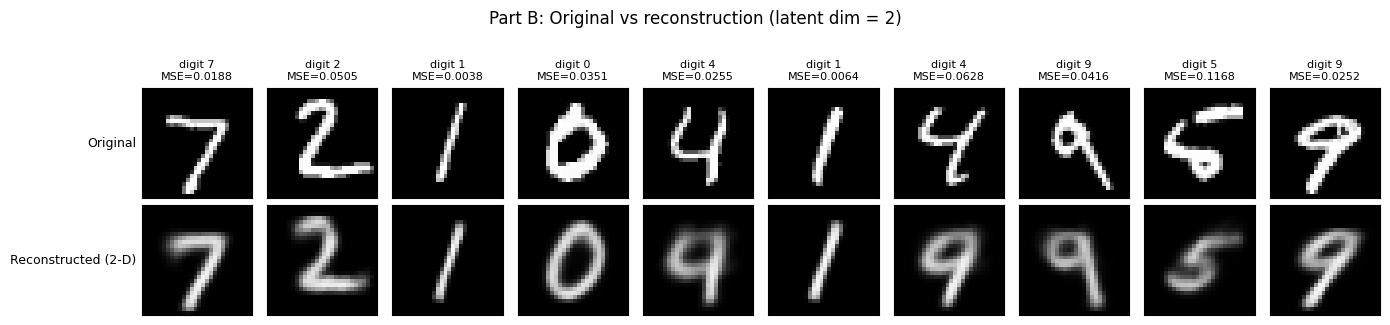

 Image #  Digit     MSE
       1      7 0.01878
       2      2 0.05049
       3      1 0.00380
       4      0 0.03511
       5      4 0.02548
       6      1 0.00638
       7      4 0.06281
       8      9 0.04160
       9      5 0.11681
      10      9 0.02521

Average MSE over these 10 images: 0.03865


In [7]:
model2 = models[2]
rec2 = reconstruct(model2, x10)
mse2 = per_image_mse(rec2, x10)

show_rows([x10, rec2], ['Original', 'Reconstructed (2-D)'],
          col_titles=[f'{t}\nMSE={m:.4f}' for t, m in zip(digit_titles, mse2)],
          title='Part B: Original vs reconstruction (latent dim = 2)')

recon_table = pd.DataFrame({'Image #': range(1, 11), 'Digit': y10, 'MSE': mse2.numpy()})
print(recon_table.to_string(index=False, float_format=lambda v: f'{v:.5f}'))
print(f'\nAverage MSE over these 10 images: {mse2.mean().item():.5f}')

## Part C: Denoising

Add Gaussian noise (std = 0.3) to the 10 test images, clip to [0, 1], and pass them through the trained VAE. Compare **clean**, **noisy** and **denoised** images. The VAE was trained only on clean images, so any denoising comes from the model projecting the noisy input onto the learned manifold of digits.

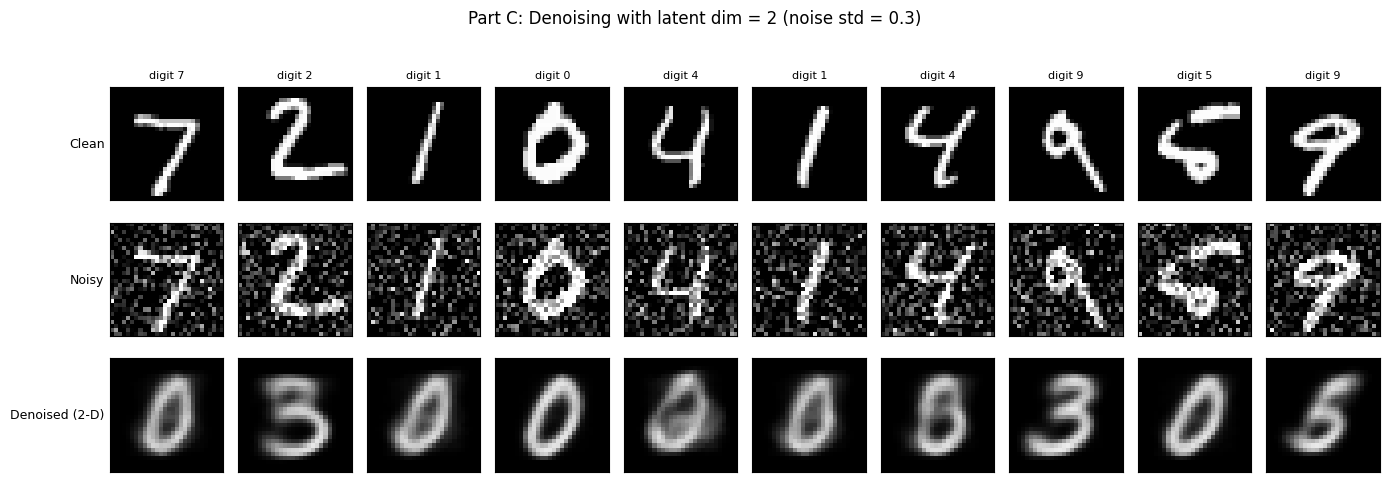

MSE(clean vs noisy)    : 0.04694
MSE(clean vs denoised) : 0.08552


In [8]:
NOISE_STD = 0.3
g = torch.Generator().manual_seed(123)
noisy10 = (x10 + NOISE_STD * torch.randn(x10.shape, generator=g)).clamp(0, 1)

den2 = reconstruct(model2, noisy10)
mse_noisy = per_image_mse(noisy10, x10)
mse_den = per_image_mse(den2, x10)

show_rows([x10, noisy10, den2], ['Clean', 'Noisy', 'Denoised (2-D)'],
          col_titles=digit_titles,
          title=f'Part C: Denoising with latent dim = 2 (noise std = {NOISE_STD})')

print(f'MSE(clean vs noisy)    : {mse_noisy.mean().item():.5f}')
print(f'MSE(clean vs denoised) : {mse_den.mean().item():.5f}')

## Part D: Changing the latent dimension (2 -> 16 -> 32)

We compare reconstruction and denoising for all three models using the same 10 images and the same noisy inputs.

In [9]:
@torch.no_grad()
def full_test_mse(model, noise_std=None):
    """Average per-image MSE over the whole 10,000-image test set.
    If noise_std is given, the input is noisy but the target is the clean image."""
    total, n = 0.0, 0
    gen = torch.Generator().manual_seed(7)
    for x, _ in test_loader:
        inp = x
        if noise_std is not None:
            inp = (x + noise_std * torch.randn(x.shape, generator=gen)).clamp(0, 1)
        rec = reconstruct(model, inp)
        total += per_image_mse(rec, x).sum().item()
        n += x.size(0)
    return total / n


def quality_label(mse):
    if mse <= 0.012: return 'Excellent (sharp, near-identical)'
    if mse <= 0.020: return 'Good (minor blur)'
    if mse <= 0.035: return 'Fair (blurry, some digits altered)'
    return 'Poor (very blurry, digits often wrong)'


noisy_baseline = float(per_image_mse(noisy10, x10).mean())
recs, dens = {}, {}
results = []
for d in latent_dims:
    m = models[d]
    recs[d] = reconstruct(m, x10)
    dens[d] = reconstruct(m, noisy10)
    rec_mse = full_test_mse(m)
    den_mse = full_test_mse(m, noise_std=NOISE_STD)
    results.append({
        'Latent dim': d,
        'Compression ratio': f'{ORIGINAL_SIZE / d:.1f} : 1',
        'Recon. MSE (10 imgs)': float(per_image_mse(recs[d], x10).mean()),
        'Recon. MSE (full test set)': rec_mse,
        'Reconstruction quality': quality_label(rec_mse),
        'Denoised MSE (full test set)': den_mse,
    })
results_df = pd.DataFrame(results)
results_df['Denoising observation'] = [
    ('Noise removed, but output is blurry / digit shape may change' if r['Latent dim'] <= 2 else
     'Noise mostly removed and digit shape kept' if r['Denoised MSE (full test set)'] < 0.7 * noisy_baseline else
     'Some noise removed; part of the noise is reproduced')
    for r in results
]
pd.set_option('display.width', 250)
pd.set_option('display.max_colwidth', 80)
print(f'Noisy-input baseline MSE (noise std={NOISE_STD}, 10 imgs): {noisy_baseline:.5f}\n')
results_df

Noisy-input baseline MSE (noise std=0.3, 10 imgs): 0.04694



,Latent dim,Compression ratio,Recon. MSE (10 imgs),Recon. MSE (full test set),Reconstruction quality,Denoised MSE (full test set),Denoising observation
0,2,392.0 : 1,0.038648,0.035975,"Poor (very blurry, digits often wrong)",0.072149,"Noise removed, but output is blurry / digit shape may change"
1,16,49.0 : 1,0.011700,0.011621,"Excellent (sharp, near-identical)",0.059097,Some noise removed; part of the noise is reproduced
2,32,24.5 : 1,0.011308,0.010955,"Excellent (sharp, near-identical)",0.062919,Some noise removed; part of the noise is reproduced


### Comparison images: reconstruction

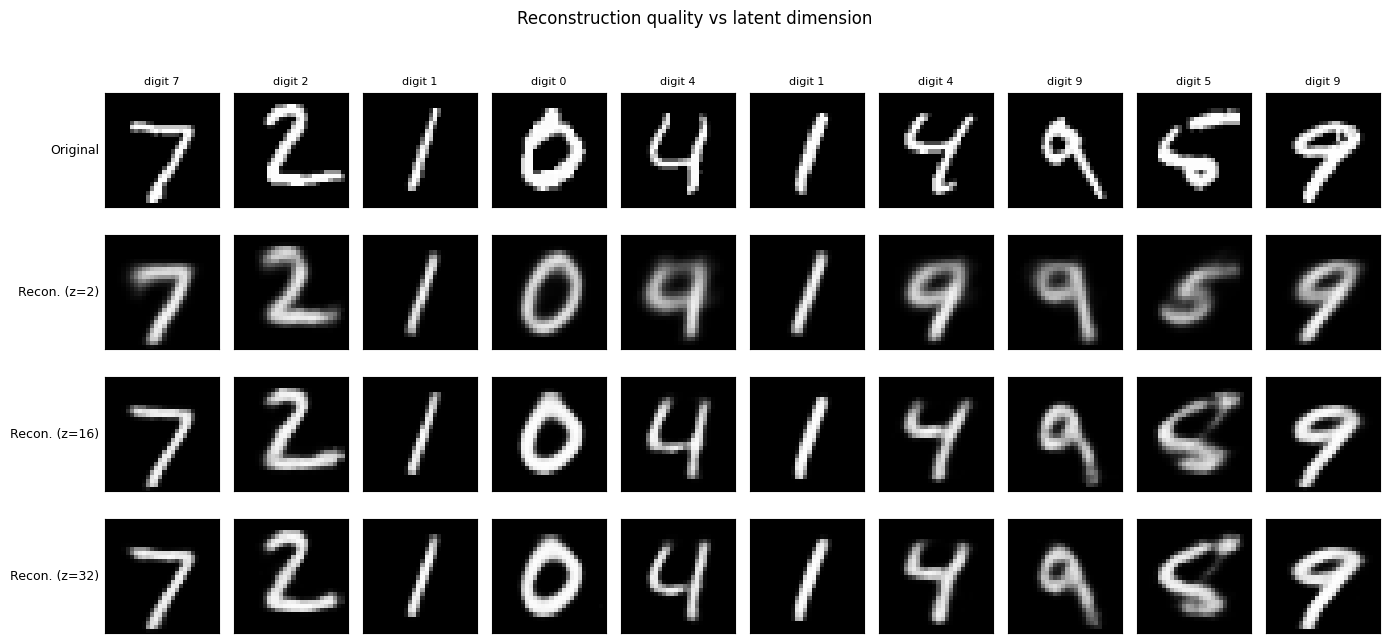

In [10]:
show_rows([x10] + [recs[d] for d in latent_dims],
          ['Original'] + [f'Recon. (z={d})' for d in latent_dims],
          col_titles=digit_titles,
          title='Reconstruction quality vs latent dimension')

### Comparison images: denoising

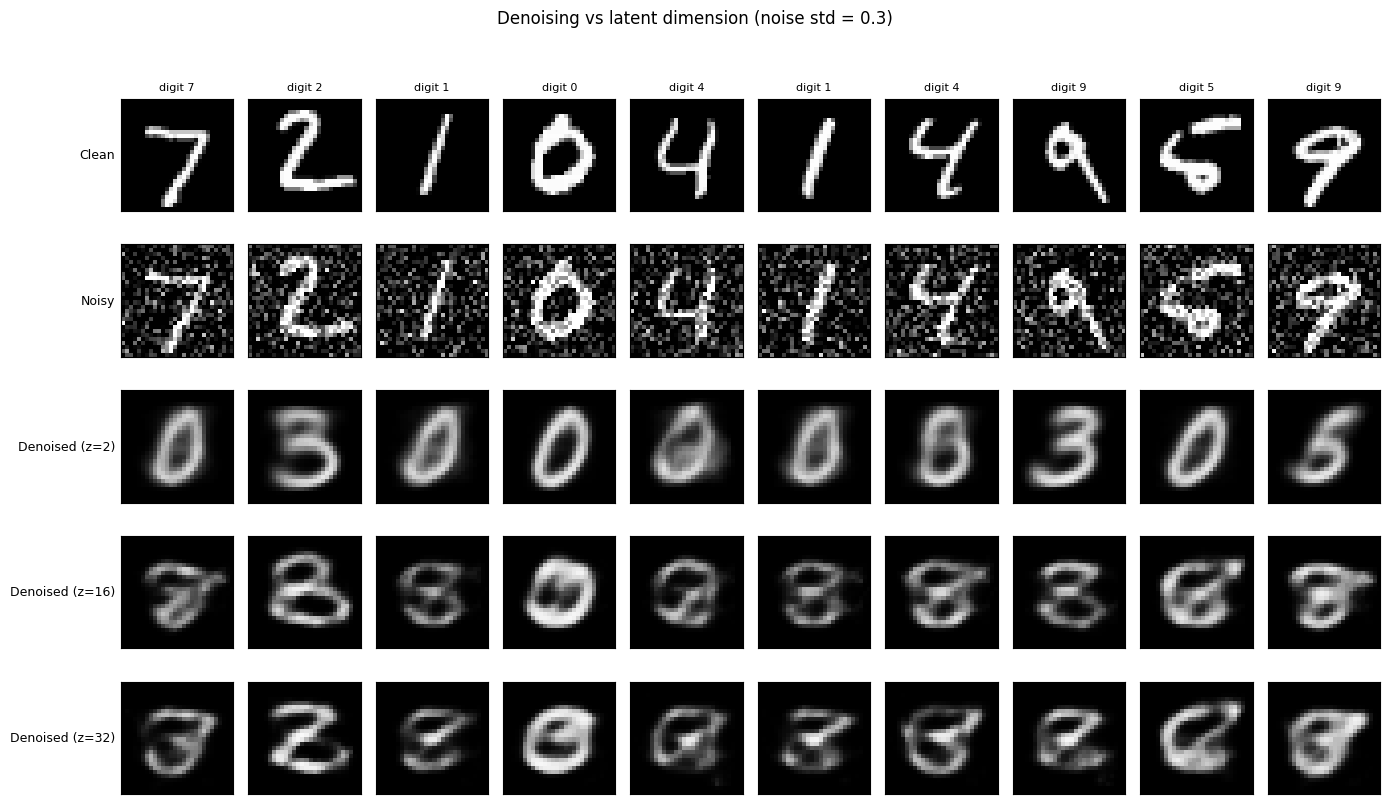

In [11]:
show_rows([x10, noisy10] + [dens[d] for d in latent_dims],
          ['Clean', 'Noisy'] + [f'Denoised (z={d})' for d in latent_dims],
          col_titles=digit_titles,
          title=f'Denoising vs latent dimension (noise std = {NOISE_STD})')

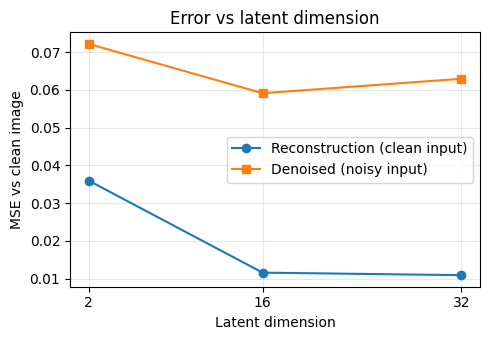

In [12]:
# Reconstruction error vs latent dimension
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(results_df['Latent dim'], results_df['Recon. MSE (full test set)'], 'o-', label='Reconstruction (clean input)')
ax.plot(results_df['Latent dim'], results_df['Denoised MSE (full test set)'], 's-', label='Denoised (noisy input)')
ax.set_xlabel('Latent dimension'); ax.set_ylabel('MSE vs clean image')
ax.set_xticks(latent_dims); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Error vs latent dimension')
plt.tight_layout(); plt.show()

## Results and Observations

The table above (generated from your own run) is the results table for submission: latent dimension, compression ratio, reconstruction error, reconstruction quality and denoising observations. The exact numbers vary slightly from run to run, but the trends below are what you should expect to see. Check them against your table and edit the wording if your results differ.

**Compression (Part A).** Going from 784 values to 2, 16 or 32 values gives compression ratios of 392:1, 49:1 and 24.5:1. A smaller latent space means stronger compression.

**Reconstruction (Parts B and D).** With a 2-D latent space the reconstructions are blurry and some digits look like a different digit (e.g. 4/9 or 3/5/8 confusions), because 2 numbers cannot hold all the detail of a digit. Increasing the latent size to 16 and 32 clearly lowers the MSE and gives sharper, more faithful images. The improvement from 16 to 32 is much smaller than from 2 to 16 (diminishing returns).

**Trade-off.** Higher latent dimension = better quality but lower compression. The 16-D model is a good balance: about 49x compression with good reconstruction.

**Denoising (Part C).** The VAE was trained on clean digits only, so passing noisy images through it removes much of the random pixel noise: the output looks like a clean, smooth digit. The 2-D model removes the most noise but also loses detail and can change the digit's identity. Larger latent sizes keep the digit shape better, but they have more capacity to reproduce some of the noise, so the denoising advantage over the noisy input is smaller. In all cases the denoised MSE (vs the clean image) is compared with the noisy MSE in the table to quantify the effect.

**Conclusion.** A VAE works as a lossy compressor (the encoder produces a small latent code, the decoder rebuilds the image) and as a simple denoiser (the latent bottleneck keeps digit structure and discards random noise). The latent dimension controls the balance between compression, reconstruction quality and denoising behaviour.